# STEP 2. Cityseer 네트워크 구축 (보로 + 3.2 km 버퍼, dual graph)

**목적**: STEP 1 세그먼트로 cityseer `CityNetwork`(dual graph: 세그먼트 = 노드, 교차점 = 엣지)를 만든다. simplest-path(각도) 분석은 dual에서만 가능하다.

**설계**
- **보로 단위 네트워크 + R_MAX 버퍼**: 보로 경계 안 세그먼트 = `live`, 버퍼(3.2 km) 안 세그먼트 = `dead`(통행에는 쓰이지만 결과를 보고하지 않음). 경로 길이가 R_MAX 이하라면 보로 밖으로 나갔다 들어오는 경로까지 정확히 포함된다.
- **보수적 정제**: `remove_fillers=False`(OSMnx가 이미 기하 노드를 제거함, 보로 창 사이 세그먼트 ID 일관성 유지), `remove_danglers=0`(짧은 횡단보도·연결로 보존), `merge_parallel_dist=2`(같은 길이 두 번 그려진 경우만 병합).
- **각도 비용 정의 확인**: cityseer의 simplest path 비용 = 경로를 따라 누적된 방향 변화(°). dual edge 기하 = 세그먼트 A 중점 → 교차점 → 세그먼트 B 중점이므로 교차점의 회전각 + 세그먼트 내부 굴곡이 모두 포함된다.

**출력**: `Data/derived/network/cityseer/cn_{C,S}_{borough}.*` (CityNetwork.save), `benchmark.csv`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# N2 configurational corridor
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=Brooklyn  boroughs=['B']  AREA_DIR=Data/derived/Brooklyn


In [2]:
from shapely.geometry import LineString
from cityseer.network import CityNetwork
import cityseer, logging
import matplotlib.pyplot as plt

logging.getLogger("cityseer").setLevel(logging.WARNING)
CN_DIR = NET_DIR / "cityseer"
CN_DIR.mkdir(exist_ok=True)


def build_cn(lines, **kw):
    """Small helper for synthetic tests: dict {id: LineString} -> CityNetwork (no cleaning)."""
    gdf = gpd.GeoDataFrame(geometry=list(lines.values()), index=list(lines), crs=CRS)
    return CityNetwork.from_geopandas(gdf, remove_fillers=False, remove_danglers=0, merge_parallel_dist=0, **kw)


def simplest_from(cn, src_id, max_m=100000):
    ng = cn.nodes_gdf
    idx2id = pd.Series(ng.index.values, index=ng["ns_node_idx"].values)
    vis, tree = cn.network_structure.dijkstra_tree_simplest(int(ng.loc[src_id, "ns_node_idx"]), int(max_m), SPEED)
    return {idx2id[v]: (tree[v].simpl_dist, tree[v].agg_seconds) for v in vis}

## 2-1. 합성 테스트 (각도 비용의 의미 검증)
| 케이스 | 기대값 |
|---|---|
| 직선 3개 세그먼트 | 0° |
| L자 회전 | 90° |
| 1/4 원호 (매끄러운 곡선) | ≈ 90° |
| 보도 → 횡단보도 → 반대편 보도 (S 변형에서 길 건너 공원) | ≈ 180° |
| 같은 가로 중심선을 공유 (C 변형에서 길 건너 공원) | 0° (co-frontage) |
| 격자망에서 A(u→v) = A(v→u) | 대칭 |

In [3]:
tests = {}
cn = build_cn({"a": LineString([(0, 0), (100, 0)]), "b": LineString([(100, 0), (200, 0)]),
               "c": LineString([(200, 0), (300, 0)]), "d": LineString([(300, 0), (300, 100)])})
r = simplest_from(cn, "a")
tests["straight 0°"] = r["c"][0]
tests["L-turn 90°"] = r["d"][0]

arc = [(100 * np.sin(t), 100 - 100 * np.cos(t)) for t in np.linspace(0, np.pi / 2, 20)]
cn = build_cn({"in": LineString([(-100, 0), (0, 0)]), "arc": LineString(arc),
               "out": LineString([arc[-1], (arc[-1][0], arc[-1][1] + 100)])})
tests["quarter arc ≈90°"] = simplest_from(cn, "in")["out"][0]

# 보도(y=0), 반대편 보도(y=18), x=50 횡단보도
cn = build_cn({"sw_a_left": LineString([(0, 0), (50, 0)]), "sw_a_right": LineString([(50, 0), (100, 0)]),
               "crossing": LineString([(50, 0), (50, 18)]),
               "sw_b_left": LineString([(50, 18), (0, 18)]), "sw_b_right": LineString([(100, 18), (50, 18)])})
tests["sidewalk crossing ≈180°"] = simplest_from(cn, "sw_a_left")["sw_b_left"][0]
tests["C co-frontage 0°"] = 0.0  # 같은 세그먼트 = 동일 dual 노드 → 정의상 0

# 5x5 격자 + 대각선: 대칭성
lines = {}
for i in range(5):
    for j in range(4):
        lines[f"h{i}{j}"] = LineString([(j * 100, i * 100), ((j + 1) * 100, i * 100)])
        lines[f"v{j}{i}"] = LineString([(i * 100, j * 100), (i * 100, (j + 1) * 100)])
lines["diag"] = LineString([(0, 0), (100, 100)])
cn = build_cn(lines)
ids = list(lines)
rng = np.random.default_rng(0)
asym = []
for a in rng.choice(ids, 15, replace=False):
    ra = simplest_from(cn, a)
    for b in rng.choice(ids, 15, replace=False):
        if a != b:
            rb = simplest_from(cn, b)
            asym.append(abs(ra[b][0] - rb[a][0]))
tests["grid max |A_uv - A_vu|"] = max(asym)

for k, v in tests.items():
    print(f"{k:<28} {v:8.2f}")
assert abs(tests["straight 0°"]) < 1e-6
assert abs(tests["L-turn 90°"] - 90) < 1e-3
assert abs(tests["quarter arc ≈90°"] - 90) < 1.0
assert abs(tests["sidewalk crossing ≈180°"] - 180) < 1e-3
assert tests["grid max |A_uv - A_vu|"] < 1e-3
print("✓ synthetic angular tests passed")

Parsing geometries:   0%|          | 0/4 [00:00<?, ?it/s]

Parsing geometries: 100%|██████████| 4/4 [00:00<00:00, 2591.08it/s]

Building nodes:   0%|          | 0/4 [00:00<?, ?it/s]

Building nodes: 100%|██████████| 4/4 [00:00<00:00, 4760.84it/s]

Building edges:   0%|          | 0/3 [00:00<?, ?it/s]

...

Building nodes:   0%|          | 0/41 [00:00<?, ?it/s]

Building nodes: 100%|██████████| 41/41 [00:00<00:00, 42221.08it/s]

Building edges:   0%|          | 0/100 [00:00<?, ?it/s]

Building edges: 100%|██████████| 100/100 [00:00<00:00, 53369.44it/s]

straight 0°                      0.00
L-turn 90°                      90.00
quarter arc ≈90°                90.00
sidewalk crossing ≈180°        180.00
C co-frontage 0°                 0.00
grid max |A_uv - A_vu|           0.00
✓ synthetic angular tests passed


**해석**: S 변형에서는 길 건너 마주 보는 두 공원도 보도→횡단보도→보도 경로로 180°가 된다. 반면 C 변형에서는 같은 가로 중심선을 공유해 0°이다. 그래서 C를 주 분석으로 쓰고 S는 보행시설 민감도로 쓴다.

## 2-2. 보로별 네트워크 구축 + 호출당 비용 벤치마크
- 이미 저장된 네트워크는 불러오기만 한다.
- `dijkstra_tree_simplest` / `dijkstra_tree_shortest`는 Python 호출마다 전체 노드 수만큼의 `NodeVisit` 객체를 만든다. 호출당 0.5 s를 넘으면 STEP 4에서 보로를 더 작은 타일로 나눈다.

In [4]:
boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough")
SEG_COLS = ["seg_id", "kind", "sep_sidewalk", "comp_size", "geometry"]


def get_borough_network(variant, b):
    base = CN_DIR / f"cn_{variant}_{b}"
    t0 = time.time()
    if base.with_suffix(".state.pkl").exists():
        return CityNetwork.load(base), None
    segs = gpd.read_parquet(NET_DIR / f"segments_{variant}.parquet", columns=SEG_COLS)
    poly = boroughs.loc[b, "geometry"]
    sub = segs.iloc[segs.sindex.query(poly.buffer(R_MAX), predicate="intersects")].set_index("seg_id", drop=False)
    del segs
    cn = CityNetwork.from_geopandas(sub, crs=CRS, boundary=poly, remove_fillers=False,
                                    remove_danglers=0, merge_parallel_dist=2.0)
    cn.save(base)
    ng = cn.nodes_gdf
    stats = dict(variant=variant, borough=b, segments_in=len(sub), dual_nodes=len(ng),
                 dual_edges=cn.network_structure.edge_count, live=int(ng["live"].sum()),
                 merged=int((cn.feature_status != "active").sum()), build_s=round(time.time() - t0, 1))
    return cn, stats


def benchmark(cn, v, b, n=10):
    ns = cn.network_structure
    live_idx = cn.nodes_gdf.loc[cn.nodes_gdf["live"], "ns_node_idx"].values
    srcs = np.random.default_rng(1).choice(live_idx, n, replace=False)
    rows = []
    for fn in ("dijkstra_tree_simplest", "dijkstra_tree_shortest"):
        t0 = time.time()
        nvis = [len(getattr(ns, fn)(int(s), int(R_MAX), SPEED)[0]) for s in srcs]
        rows.append(dict(variant=v, borough=b, fn=fn, sec_per_call=(time.time() - t0) / n,
                         visited_mean=np.mean(nvis), nodes=len(cn.nodes_gdf)))
    return rows


net_stats, bench = [], []
cn_plot = None
for v in VARIANTS:
    for b in AREA_BOROUGHS:
        cn, st = get_borough_network(v, b)
        if st:
            print(st)
            net_stats.append(st)
        bench += benchmark(cn, v, b)
        if v == PRIMARY and b == AREA_BOROUGHS[0]:
            cn_plot = cn.to_geopandas()[["live", "geometry"]]
        del cn
if net_stats:
    p = NET_DIR / "cityseer_network_stats.csv"
    old = pd.read_csv(p) if p.exists() else pd.DataFrame()
    pd.concat([old, pd.DataFrame(net_stats)]).drop_duplicates(["variant", "borough"], keep="last").to_csv(p, index=False)
bench = pd.DataFrame(bench)
bench.to_csv(AREA_DIR / "benchmark.csv", index=False)
display(pd.read_csv(NET_DIR / "cityseer_network_stats.csv"))
bench.round(3)

Parsing geometries:   0%|          | 0/166967 [00:00<?, ?it/s]

Parsing geometries:   2%|▏         | 3933/166967 [00:00<00:04, 39319.73it/s]

Parsing geometries:   5%|▍         | 7869/166967 [00:00<00:04, 39340.62it/s]

Parsing geometries:   7%|▋         | 11814/166967 [00:00<00:03, 39388.22it/s]

Parsing geometries:   9%|▉         | 15753/166967 [00:00<00:03, 39339.36it/s]

...

Building edges: 100%|█████████▉| 926162/927843 [00:28<00:00, 36174.86it/s]

Building edges: 100%|██████████| 927843/927843 [00:28<00:00, 33019.51it/s]

{'variant': 'S', 'borough': 'B', 'segments_in': 408745, 'dual_nodes': 408322, 'dual_edges': 1855686, 'live': 254797, 'merged': 423, 'build_s': 81.1}


,variant,borough,segments_in,dual_nodes,dual_edges,live,merged,build_s
0,C,B,166967,166522,560110,93188,445,32.5
1,S,B,408745,408322,1855686,254797,423,81.1


,variant,borough,fn,sec_per_call,visited_mean,nodes
0,C,B,dijkstra_tree_simplest,0.078,9905.3,166522
1,C,B,dijkstra_tree_shortest,0.012,10789.0,166522
2,S,B,dijkstra_tree_simplest,0.248,30153.8,408322
3,S,B,dijkstra_tree_shortest,0.029,34138.8,408322


## 2-3. 시각 확인: 주 분석 네트워크(C)의 live / dead

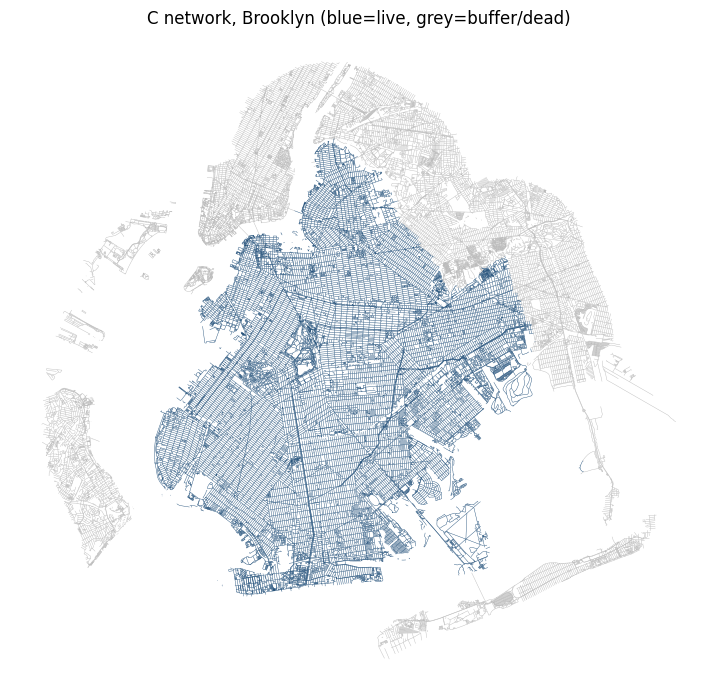

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))
cn_plot[~cn_plot["live"]].plot(ax=ax, color="#bbbbbb", linewidth=0.3)
cn_plot[cn_plot["live"]].plot(ax=ax, color="#1f4e79", linewidth=0.3)
ax.set_title(f"{PRIMARY} network, {BOROUGHS[AREA_BOROUGHS[0]]} (blue=live, grey=buffer/dead)")
ax.set_axis_off()
plt.show()